In [1]:
from dotenv import load_dotenv
import os

env_path = '/teamspace/studios/this_studio/Deeplab/credentials.env'
load_dotenv(dotenv_path=env_path)
import boto3

In [9]:
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
import cv2

def display_probability_heatmap(base_dir, filename, figsize=(18, 6), alpha=0.5, cmap='viridis'):
    """
    Display an image alongside its probability map as a heatmap.
    
    Parameters:
    -----------
    base_dir : str
        Base directory containing the 'samples' and 'probs' folders
    filename : str
        Base filename without extension (e.g., 'image1' for 'image1.jpg')
    figsize : tuple, optional
        Figure size (width, height) in inches
    alpha : float, optional
        Transparency of the overlay (0.0 to 1.0)
    cmap : str, optional
        Colormap to use for the heatmap (default: 'viridis')
    
    Returns:
    --------
    fig : matplotlib.figure.Figure
        The figure containing the visualizations
    """
    # Construct paths
    filename=os.path.splitext(filename)[0]
    image_path = os.path.join(base_dir, 'samples', f"{filename}.jpg")
    prob_path = os.path.join(base_dir, 'probs', f"{filename}_prob.npy")
    
    # Check if files exist
    if not os.path.exists(image_path):
        raise FileNotFoundError(f"Image file not found: {image_path}")
    if not os.path.exists(prob_path):
        raise FileNotFoundError(f"Probability file not found: {prob_path}")
    
    # Load the image and probability map
    image = cv2.imread(image_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)  # Convert BGR to RGB
    prob_map = np.load(prob_path)
    
    # Create figure with 3 subplots
    fig, axes = plt.subplots(1, 3, figsize=figsize)
    
    # Plot the original image
    axes[0].imshow(image)
    axes[0].set_title('Original Image')
    axes[0].axis('off')
    
    # Plot the probability heatmap
    heatmap = axes[1].imshow(prob_map, cmap=cmap)
    axes[1].set_title('Probability Heatmap')
    axes[1].axis('off')
    fig.colorbar(heatmap, ax=axes[1], fraction=0.046, pad=0.04)
    
    # Plot the overlay of the probability on the image
    axes[2].imshow(image)
    overlay = axes[2].imshow(prob_map, cmap=cmap, alpha=alpha)
    axes[2].set_title('Overlay')
    axes[2].axis('off')
    fig.colorbar(overlay, ax=axes[2], fraction=0.046, pad=0.04)
    
    plt.tight_layout()
    return fig

In [5]:
%cd Deeplab


/teamspace/studios/this_studio/segmentation_model_build/segmentation_model_build/Deeplab


/home/zeus/miniconda3/envs/cloudspace/lib/python3.10/site-packages/IPython/core/magics/osm.py:417: UserWarning: using dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


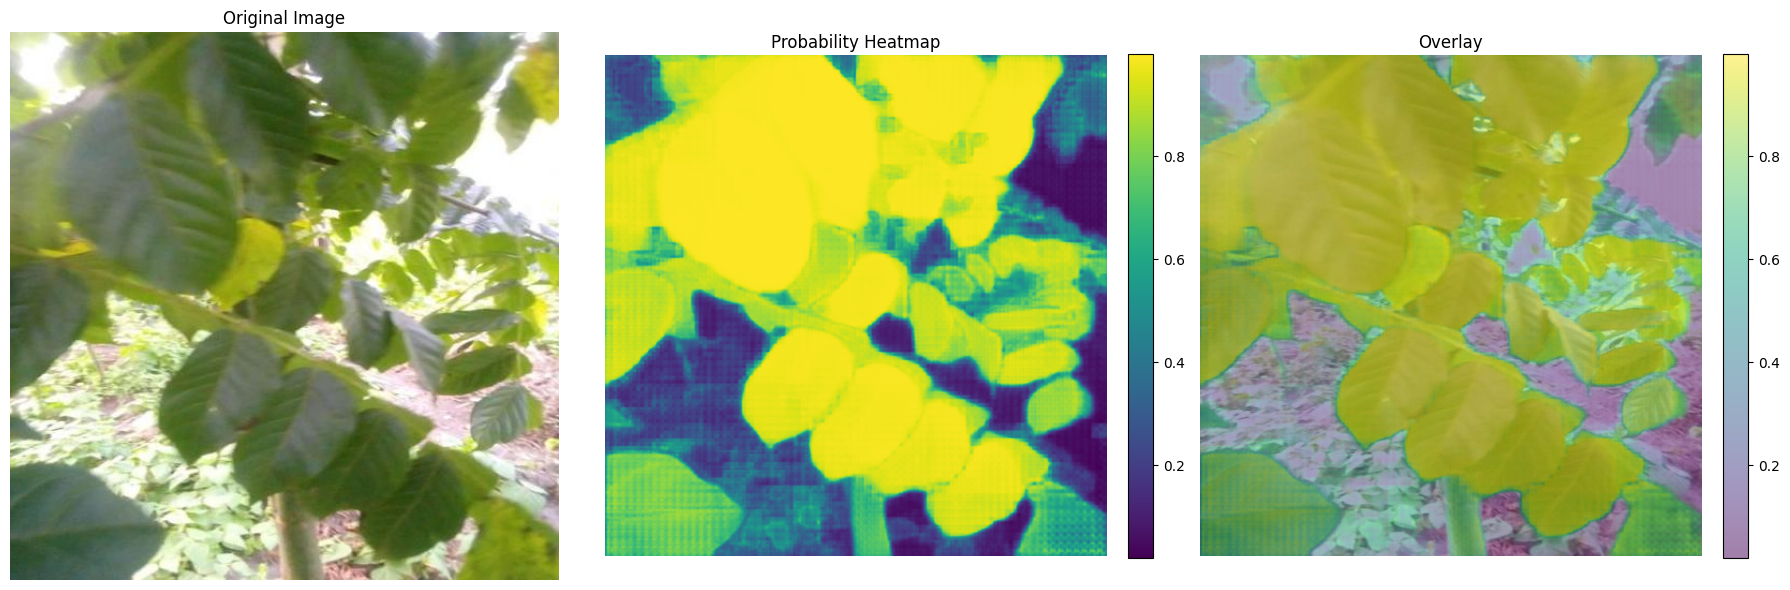

In [ ]:
base_dir = 'crf_sam_annotations_large'
import os
#samples = os.listdir(base_dir)
display_probability_heatmap(base_dir,samples[0])

In [8]:
%cd Deeplab
from inference.infer import *

[Errno 2] No such file or directory: 'Deeplab'
/mnt/data/greenstand/old_deeplab/segmentation_model_build/Deeplab


In [63]:
from inference.infer import *

In [3]:
bucket = get_s3_bucket('treetracker-training-images')
print(type(bucket))

<class 'boto3.resources.factory.s3.Bucket'>


In [2]:
import torch
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
import pandas as pd
import boto3
import matplotlib.pyplot as plt
import os
#img_link = 'https://treetracker-production-images.s3.eu-central-1.amazonaws.com/2021.03.28.12.34.59_-4.531118333333334_38.248731666666664_6973c014-d0e7-4fa8-a80f-9495bfc8af3d_IMG_20210322_094829_8180242403936928723.jpg'
inhouse_default = 'saved_models/best_deeplabv3plus_mobilenet_custom_os16_0.7854892764326529.pth'


In [4]:
import numpy as np
import pydensecrf.densecrf as dcrf
from pydensecrf.utils import unary_from_labels, create_pairwise_bilateral, create_pairwise_gaussian

def crf_with_prob(img, mask, prob):
    """
    Applies DenseCRF to refine the segmentation mask.
    
    Args:
    - img (numpy array): The original image.
    - mask (numpy array): The initial segmentation mask.
    - prob (numpy array): The probability array indicating likelihood of pixels being in the foreground.
    
    Returns:
    - refined_mask (numpy array): The refined segmentation mask.
    """
    # Convert image to numpy array if it's a tensor
    if isinstance(img, torch.Tensor):
        img = img.numpy().transpose(1, 2, 0)

    # Get height and width of image
    h, w = img.shape[:2]

    # Ensure mask is a 2D array
    if mask.ndim == 3 and mask.shape[0] == 1:
        mask = mask[0]
    elif mask.ndim == 3 and mask.shape[0] == 3:  # In case the mask is RGB
        mask = mask[0]

    # Ensure mask has the same height and width as the image
    assert mask.shape == (h, w), f"Mask shape {mask.shape} does not match image shape {(h, w)}"

    # Initialize DenseCRF
    d = dcrf.DenseCRF2D(w, h, 2)

    # Create unary potentials
# Create unary potentials
    mask = mask.astype(np.float32) / 255.0  # Normalize mask to range [0, 1]
    #unary_bg = 1 - prob  # Background unary potential
    #unary_fg = prob  # Foreground unary potential
    unary = np.stack([prob, 1 - prob], axis=0) 
    unary = unary.reshape((2, -1))
    #unary = np.stack([unary_bg, unary_fg], axis=-1)  # Stack to create unary potentials
    d.setUnaryEnergy(unary)


    # Create pairwise potentials
    pairwise_gaussian = create_pairwise_gaussian(sdims=(3, 3), shape=img.shape[:2])
    d.addPairwiseEnergy(pairwise_gaussian, compat=3)

    pairwise_bilateral = create_pairwise_bilateral(sdims=(50, 50), schan=(13, 13, 13), img=img, chdim=2)
    d.addPairwiseEnergy(pairwise_bilateral, compat=10)

    # Perform inference
    Q = d.inference(5)
    refined_mask = np.argmax(Q, axis=0).reshape((h, w))

    return refined_mask
    
def apply_dense_crf(img, mask):
    """
    Applies DenseCRF to refine the segmentation mask.
    
    Args:
    - img (numpy array): The original image.
    - mask (numpy array): The initial segmentation mask.
    
    Returns:
    - refined_mask (numpy array): The refined segmentation mask.
    """
    # Convert image to numpy array if it's a tensor
    if isinstance(img, torch.Tensor):
        print('lala')
        img = img.numpy().transpose(1, 2, 0)

    # Get height and width of image
    h, w = img.shape[:2]

    # Ensure mask is a 2D array
    if mask.ndim == 3 and mask.shape[0] == 1:
        print('hi')
        mask = mask[0]
    elif mask.ndim == 3 and mask.shape[0] == 3:
        print('hello')
        # In case the mask is RGB
        mask = mask[0]

    # Ensure mask has the same height and width as the image
    assert mask.shape == (h, w), f"Mask shape {mask.shape} does not match image shape {(h, w)}"

    # Initialize DenseCRF
    d = dcrf.DenseCRF2D(w, h, 2)

    # Create unary potentials
    mask = mask.astype(np.float32) / 255.0  # Normalize mask to range [0, 1]
    unary = np.stack([mask, 1 - mask], axis=0)  # Swapped to correctly represent foreground and background
    unary = unary.reshape((2, -1))  # Shape should be (num_classes, height*width)
    d.setUnaryEnergy(unary)

    # Create pairwise potentials
    pairwise_gaussian = create_pairwise_gaussian(sdims=(3, 3), shape=img.shape[:2])
    d.addPairwiseEnergy(pairwise_gaussian, compat=3)

    pairwise_bilateral = create_pairwise_bilateral(sdims=(50, 50), schan=(13, 13, 13), img=img, chdim=2)
    d.addPairwiseEnergy(pairwise_bilateral, compat=10)

    # Perform inference
    Q = d.inference(5)
    refined_mask = np.argmax(Q, axis=0).reshape((h, w))

    return refined_mask

In [10]:
class BinarySegMetrics():
    """
    Binary Segmentation
    """
    def __init__(self):
        # two classes (foreground and background)
        self.n_classes = 2
        self.confusion_matrix = np.zeros((2, 2))
        # self.threshold = 0.5  # Threshold for converting probabilities to binary predictions

    def _fast_hist(self, label_true, label_pred):
        # label_pred = label_pred >= self.threshold  # Binarize predictions
        mask = (label_true >= 0) & (label_true < self.n_classes)
        hist = np.bincount(
            2 * label_true[mask].astype(int) + label_pred[mask],
            minlength=self.n_classes ** 2,
        ).reshape(self.n_classes, self.n_classes)
        return hist

    def update(self, label_trues, label_preds):
        for lt, lp in zip(label_trues, label_preds):
            self.confusion_matrix += self._fast_hist(lt.flatten(), lp.flatten())

    def get_results(self):
        """Returns accuracy score evaluation result for binary segmentation."""
        hist = self.confusion_matrix
        tn, fp, fn, tp = hist.ravel()
        
        # Metrics for foreground
        foreground_total = tp + fn
        foreground_acc = tp / foreground_total if foreground_total > 0 else 0
        
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0
        f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

        iou_foreground = tp / (tp + fn + fp) if (tp + fn + fp) > 0 else 0
        iou_background = tn / (tn + fp + fn) if (tn + fp + fn) > 0 else 0
        mean_iou = (iou_foreground + iou_background) / 2

        #overall_acc = np.diag(hist).sum() / hist.sum()

        return {
            "Foreground Acc": foreground_acc,
            "Precision": precision,
            "Recall": recall,
            "F1 Score": f1_score,
            "IoU Foreground": iou_foreground,
            "IoU Background": iou_background,
            "Mean IoU": mean_iou
        }

    def reset(self):
        self.confusion_matrix = np.zeros((self.n_classes, self.n_classes))

    @staticmethod
    def to_str(results):
        string = "\n"
        for k, v in results.items():
            string += "%s: %f\n" % (k, v)
        return string

In [29]:
from tqdm import tqdm
import os
from PIL import Image
import numpy as np
import torch
from torchvision import transforms

# Assuming these functions and classes are defined somewhere in your code
# from your_code import BinarySegMetrics, load_deeplab_model, utils

def get_target(mask_path,device):
    mask = Image.open(mask_path)
    mask_array = np.array(mask)
    mask_array = (mask_array > 128).astype(np.uint8)
    mask_array = mask_array * 255
    mask = Image.fromarray(mask_array.astype(np.uint8))
    mask = mask_transform(mask)
    mask = torch.squeeze(mask, 0)
    mask = mask.to(device, dtype=torch.long)
    mask = mask.float()
    return mask.cpu().numpy()

def metrics_from_dataset(checkpoint, dataset_path):
    metrics = BinarySegMetrics()
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = load_deeplab_model(checkpoint, device).eval()
    sample_dir = os.path.join(dataset_path, 'samples')
    mask_dir = os.path.join(dataset_path, 'binary_masks')
    
    file_list = os.listdir(sample_dir)
    
    for i in tqdm(file_list, desc="Processing images"):
        img_path = os.path.join(sample_dir, i)
        ext = os.path.basename(img_path).split('.')[-1]
        img_name = os.path.basename(img_path)[:-len(ext) - 1]
        mask_path = os.path.join(mask_dir, img_name + '_binarymask.' + ext)
        
        target = get_target(mask_path)
        img = Image.open(img_path)
        
        img_transform = transforms.Compose([
            transforms.Resize((512, 512)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        ])
        img_tensor = img_transform(img).unsqueeze(0).to(device, dtype=torch.float32)
    
        with torch.no_grad():
            output = model(img_tensor)
            output = torch.squeeze(output, dim=1)
            prob = torch.sigmoid(output).detach()
            pred = (prob > 0.5).long().cpu().numpy()[0]
            
        metrics.update(target, pred)
        
        # The following lines are commented out as they appear to be part of additional processing
        # denorm = utils.Denormalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        # img_np = img_tensor[0].detach().cpu().numpy()
        # img_np = (denorm(img_np) * 255).transpose(1, 2, 0).astype(np.uint8)
        # cleaned_mask = apply_dense_crf(img_np, np.array(decode_target(pred)))
        # prob_np = prob[0].cpu().numpy()
        # count = np.sum(prob_np > 0.5)
        # confidence = np.sum(prob_np[prob_np > 0.5]) / count if count != 0 else 0
        
    return metrics.get_results()


In [72]:
def get_target(mask_path,device):
    mask = Image.open(mask_path)
    mask_array = np.array(mask)
    mask_array = (mask_array > 128).astype(np.uint8)
    mask_array = mask_array * 255
    mask = Image.fromarray(mask_array.astype(np.uint8))
    mask = mask_transform(mask)
    mask = torch.squeeze(mask, 0)
    mask = mask.to(device, dtype=torch.long)
    mask = mask.float()
    return mask.cpu().numpy()

def metrics_from_dataset(device, checkpoint, dataset_path, approved_json):
    with open(approved_json, "r") as f:
        approved_list = json.load(f)
    metrics = BinarySegMetrics()
    #device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = load_deeplab_model(checkpoint, device).eval()
    sample_dir = os.path.join(dataset_path, 'samples')
    mask_dir = os.path.join(dataset_path, 'binary_masks')
    
    file_list = approved_list
    
    for i in tqdm(file_list, desc="Processing images"):
        img_path = os.path.join(sample_dir, i)
        ext = os.path.basename(img_path).split('.')[-1]
        img_name = os.path.basename(img_path)[:-len(ext) - 1]
        mask_path = os.path.join(mask_dir, img_name + '_binarymask.' + ext)
        
        target = get_target(mask_path,device)
        img = Image.open(img_path)
        
        img_transform = transforms.Compose([
            transforms.Resize((512, 512)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        ])
        img_tensor = img_transform(img).unsqueeze(0).to(device, dtype=torch.float32)
    
        with torch.no_grad():
            output = model(img_tensor)
            output = torch.squeeze(output, dim=1)
            prob = torch.sigmoid(output).detach()
            pred = (prob > 0.5).long().cpu().numpy()[0]
            
        metrics.update(target, pred)
        
        # The following lines are commented out as they appear to be part of additional processing
        # denorm = utils.Denormalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        # img_np = img_tensor[0].detach().cpu().numpy()
        # img_np = (denorm(img_np) * 255).transpose(1, 2, 0).astype(np.uint8)
        # cleaned_mask = apply_dense_crf(img_np, np.array(decode_target(pred)))
        # prob_np = prob[0].cpu().numpy()
        # count = np.sum(prob_np > 0.5)
        # confidence = np.sum(prob_np[prob_np > 0.5]) / count if count != 0 else 0
        
    return metrics.get_results()

In [59]:
import json

with open("india_sam_dino_annotations_large/approved.json", "r") as f:
    data_list = json.load(f)

print(data_list[0])  # ['sample1.jpg', 'sample2.jpg', 'sample3.jpg']


india_psidguaj (guava)2020.12.25.18.04.48_25.23552198_79.32372180800003_4eccc4d4-d63d-4477-9dfb-fc6159fb0724_img_20201224_103737_4443765858459793946.jpg


In [22]:
print(os.path.exists('inhouse/binary_masks/haiti_ACACAURI_6_soilflag=0_binarymask.jpg'))

True


In [23]:
masks = os.listdir('inhouse/binary_masks')

In [25]:
for mask in masks:
    os.rename(f'inhouse/binary_masks/{mask}', f'inhouse/binary_masks/{mask.lower()}')

In [36]:
dataset_path = 'india_sam_dino_annotations_large'
samples_dir = os.path.join(dataset_path, 'samples')
samples_list = os.listdir(samples_dir)
print(len(samples_list))

4315


In [47]:
kl_path = 'saved_models/kl_check_temp_2_weighted.pth'

In [38]:
metrics_from_dataset(inhouse_default , '/home/neel/mnt_data/greenstand/old_deeplab/segmentation_model_build/Deeplab/india_sam_dino_annotations_large')

Device: cuda
Resume model from saved_models/best_deeplabv3plus_mobilenet_custom_os16_0.7854892764326529.pth
Model device: cuda:0


Processing images: 100%|████████████████████████████████████████████████████████████████████████████████████| 4071/4071 [01:45<00:00, 38.72it/s]


{'Foreground Acc': np.float64(0.7375292550119134),
 'Precision': np.float64(0.9426231342180043),
 'Recall': np.float64(0.7375292550119134),
 'F1 Score': np.float64(0.8275584314770918),
 'IoU Foreground': np.float64(0.7058419401827294),
 'IoU Background': np.float64(0.9351283616102284),
 'Mean IoU': np.float64(0.8204851508964789)}

In [55]:
def load_deeplab_model(ckpt, device, model_type='deeplabv3plus_mobilenet', num_classes=1, output_stride=16):
    os.environ['CUDA_VISIBLE_DEVICES'] = '0'
    print("Device: %s" % device)
    
    # Create the model with EXACTLY the same configuration as training
    model = network.modeling.__dict__[model_type](num_classes, output_stride)
    
    # Don't apply separable convolution since it was False during training
    # network.convert_to_separable_conv(model.classifier)  <- COMMENT THIS OUT
    
    utils.set_bn_momentum(model.backbone, momentum=0.01)
    
    # Load the checkpoint
    checkpoint = torch.load(ckpt, map_location=torch.device('cuda'), weights_only=False)
    model.load_state_dict(checkpoint["model_state"])
    
    model = nn.DataParallel(model)
    model.to(device)
    
    print("Resume model from %s" % ckpt)
    del checkpoint
    print(f"Model device: {next(model.parameters()).device}")
    return model

In [56]:
model = load_deeplab_model(kl_path,'cuda')

Device: cuda
Resume model from saved_models/kl_check_temp_2_weighted.pth
Model device: cuda:0


In [57]:
metrics_from_dataset(kl_path , '/home/neel/mnt_data/greenstand/old_deeplab/segmentation_model_build/Deeplab/inhouse')

Device: cuda
Resume model from saved_models/kl_check_temp_2_weighted.pth
Model device: cuda:0


Processing images: 100%|██████████████████████████████████████████████████████████████████████████████████████| 244/244 [00:06<00:00, 40.53it/s]


{'Foreground Acc': np.float64(0.9490786557918804),
 'Precision': np.float64(0.7711166892046327),
 'Recall': np.float64(0.9490786557918804),
 'F1 Score': np.float64(0.8508921884688643),
 'IoU Foreground': np.float64(0.7404807276830604),
 'IoU Background': np.float64(0.9389908712905716),
 'Mean IoU': np.float64(0.839735799486816)}

In [62]:
metrics_from_dataset(kl_path , '/home/neel/mnt_data/greenstand/old_deeplab/segmentation_model_build/Deeplab/india_sam_dino_annotations_large','india_sam_dino_annotations_large/approved.json')

Device: cuda
Resume model from saved_models/kl_check_temp_2_weighted.pth
Model device: cuda:0


Processing images: 100%|██████████████████████████████████████████████████████████████████████████████████████| 207/207 [00:05<00:00, 41.09it/s]


{'Foreground Acc': np.float64(0.872678657437919),
 'Precision': np.float64(0.8655324149538818),
 'Recall': np.float64(0.872678657437919),
 'F1 Score': np.float64(0.8690908461555331),
 'IoU Foreground': np.float64(0.7684886475638683),
 'IoU Background': np.float64(0.9443476872299043),
 'Mean IoU': np.float64(0.8564181673968863)}

In [65]:
def load_deeplab_model(ckpt, device, model_type='deeplabv3plus_mobilenet', num_classes=1, output_stride=16):
    os.environ['CUDA_VISIBLE_DEVICES'] = '0'
    print("Device: %s" % device)

    model = network.modeling.__dict__[model_type](num_classes, output_stride)
    network.convert_to_separable_conv(model.classifier)
    utils.set_bn_momentum(model.backbone, momentum=0.01)
    checkpoint = torch.load(ckpt, map_location=torch.device('cuda'), weights_only=False)

    model.load_state_dict(checkpoint["model_state"])
    model = nn.DataParallel(model)
    model.to(device)
    print("Resume model from %s" % ckpt)
    del checkpoint
    print(f"Model device: {next(model.parameters()).device}")
    return model

In [70]:
device = 'cuda'

In [73]:
metrics_from_dataset(device,inhouse_default , '/home/neel/mnt_data/greenstand/old_deeplab/segmentation_model_build/Deeplab/india_sam_dino_annotations_large','india_sam_dino_annotations_large/approved.json')

Device: cuda
Resume model from saved_models/best_deeplabv3plus_mobilenet_custom_os16_0.7854892764326529.pth
Model device: cuda:0


Processing images: 100%|██████████████████████████████████████████████████████████████████████████████████████| 207/207 [00:04<00:00, 42.37it/s]


{'Foreground Acc': np.float64(0.7636001811095331),
 'Precision': np.float64(0.9550016968590629),
 'Recall': np.float64(0.7636001811095331),
 'F1 Score': np.float64(0.8486426996617272),
 'IoU Foreground': np.float64(0.7370802264530683),
 'IoU Background': np.float64(0.9436421402506153),
 'Mean IoU': np.float64(0.8403611833518418)}

In [19]:
metrics_from_dataset(downstreamed_large , '/teamspace/studios/this_studio/Deeplab/pilot_annotations_eastafrica_haiti_freetown')

Device: cpu
Resume model from /teamspace/studios/this_studio/Deeplab/saved_models/india_sam_dino_250_samples_0.8495187035894669.pth


Processing images: 100%|██████████| 244/244 [00:57<00:00,  4.23it/s]


{'Foreground Acc': 0.9380342308466383,
 'Precision': 0.7545361416772415,
 'Recall': 0.9380342308466383,
 'F1 Score': 0.8363383180916639,
 'IoU Foreground': 0.7187126044402515,
 'IoU Background': 0.9324888227374449,
 'Mean IoU': 0.8256007135888482}

In [22]:
    def decode_target_single_channel(mask):
      leaf_color = [255]
      rgb_mask = np.zeros((mask.shape[0], mask.shape[1]), dtype=np.uint8)
      rgb_mask[mask == 1] = leaf_color
      return Image.fromarray(rgb_mask)

In [16]:
from tqdm import tqdm
import os
from PIL import Image
import numpy as np
import torch
from torchvision import transforms

# Assuming these functions and classes are defined somewhere in your code
# from your_code import BinarySegMetrics, load_deeplab_model, utils


def get_target(mask_path):
    mask = Image.open(mask_path)
    mask_array = np.array(mask)
    mask_array = (mask_array > 128).astype(np.uint8)
    mask_array = mask_array * 255
    mask = Image.fromarray(mask_array.astype(np.uint8))
    mask = mask_transform(mask)
    mask = torch.squeeze(mask, 0)
    mask = mask.to(device, dtype=torch.long)
    mask = mask.float()
    return mask.cpu().numpy()

def metrics_from_dataset_crf(checkpoint, dataset_path, with_prob = True):
    metrics = BinarySegMetrics()
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = load_deeplab_model(checkpoint, device).eval()
    sample_dir = os.path.join(dataset_path, 'samples')
    mask_dir = os.path.join(dataset_path, 'binary_masks')
    
    file_list = os.listdir(sample_dir)
    
    for i in tqdm(file_list, desc="Processing images"):
        img_path = os.path.join(sample_dir, i)
        ext = os.path.basename(img_path).split('.')[-1]
        img_name = os.path.basename(img_path)[:-len(ext) - 1]
        mask_path = os.path.join(mask_dir, img_name + '_binarymask.' + ext)
        
        target = get_target(mask_path)
        img = Image.open(img_path)
        
        img_transform = transforms.Compose([
            transforms.Resize((512, 512)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        ])
        img_tensor = img_transform(img).unsqueeze(0).to(device, dtype=torch.float32)
    
        with torch.no_grad():
            output = model(img_tensor)
            output = torch.squeeze(output, dim=1)
            prob = torch.sigmoid(output).detach()
            pred = (prob > 0.5).long().cpu().numpy()[0]
            
        denorm = utils.Denormalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        img_np = img_tensor[0].detach().cpu().numpy() 
        img_np = (denorm(img_np) * 255).transpose(1, 2, 0).astype(np.uint8)
        
        if with_prob:
            prob_np = prob[0].cpu().numpy()
            cleaned_mask = crf_with_prob(img_np,np.array(decode_target_single_channel(pred)),prob_np)
        else:
            cleaned_mask = apply_dense_crf(img_np,np.array(decode_target_single_channel(pred)))
        
        metrics.update(target, cleaned_mask)
        
        # The following lines are commented out as they appear to be part of additional processing
        # denorm = utils.Denormalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        # img_np = img_tensor[0].detach().cpu().numpy()
        # img_np = (denorm(img_np) * 255).transpose(1, 2, 0).astype(np.uint8)
        # cleaned_mask = apply_dense_crf(img_np, np.array(decode_target(pred)))
        # prob_np = prob[0].cpu().numpy()
        # count = np.sum(prob_np > 0.5)
        # confidence = np.sum(prob_np[prob_np > 0.5]) / count if count != 0 else 0
        
    return metrics.get_results()


In [28]:
metrics_from_dataset_crf(downstreamed_small , '/teamspace/studios/this_studio/Deeplab/pilot_annotations_eastafrica_haiti_freetown')

Device: cpu
Resume model from /teamspace/studios/this_studio/Deeplab/saved_models/india_sam_dino_250_samples_0.8940880817269634.pth


Processing images: 100%|██████████| 244/244 [02:34<00:00,  1.58it/s]


{'Foreground Acc': 0.9160747257553932,
 'Precision': 0.798393206203032,
 'Recall': 0.9160747257553932,
 'F1 Score': 0.8531951211032012,
 'IoU Foreground': 0.7439758382646191,
 'IoU Background': 0.9422615949020791,
 'Mean IoU': 0.8431187165833491}

In [36]:
metrics_from_dataset_crf(downstreamed_small , '/teamspace/studios/this_studio/Deeplab/pilot_annotations_eastafrica_haiti_freetown')

Device: cpu
Resume model from /teamspace/studios/this_studio/Deeplab/saved_models/india_sam_dino_250_samples_0.8940880817269634.pth


Processing images: 100%|██████████| 244/244 [02:38<00:00,  1.54it/s]


{'Foreground Acc': 0.9139133053404319,
 'Precision': 0.801892623684875,
 'Recall': 0.9139133053404319,
 'F1 Score': 0.8542461893184728,
 'IoU Foreground': 0.7455756911777957,
 'IoU Background': 0.9429032044835403,
 'Mean IoU': 0.844239447830668}

In [38]:
metrics_from_dataset_crf(downstreamed_large , '/teamspace/studios/this_studio/Deeplab/pilot_annotations_eastafrica_haiti_freetown', with_prob = False)

Device: cpu
Resume model from /teamspace/studios/this_studio/Deeplab/saved_models/india_sam_dino_250_samples_0.8495187035894669.pth


Processing images: 100%|██████████| 244/244 [02:36<00:00,  1.56it/s]


{'Foreground Acc': 0.9337117887475953,
 'Precision': 0.8031100370781444,
 'Recall': 0.9337117887475953,
 'F1 Score': 0.8635005596211557,
 'IoU Foreground': 0.7597896918746513,
 'IoU Background': 0.945758960694387,
 'Mean IoU': 0.8527743262845191}

In [39]:
metrics_from_dataset_crf(downstreamed_large , '/teamspace/studios/this_studio/Deeplab/pilot_annotations_eastafrica_haiti_freetown', with_prob = True)

Device: cpu
Resume model from /teamspace/studios/this_studio/Deeplab/saved_models/india_sam_dino_250_samples_0.8495187035894669.pth


Processing images: 100%|██████████| 244/244 [02:37<00:00,  1.55it/s]


{'Foreground Acc': 0.9287126006633486,
 'Precision': 0.8080516469691839,
 'Recall': 0.9287126006633486,
 'F1 Score': 0.8641906897266276,
 'IoU Foreground': 0.7608589592549031,
 'IoU Background': 0.9464142318485465,
 'Mean IoU': 0.8536365955517248}

In [40]:
metrics_from_dataset(inhouse_default , '/teamspace/studios/this_studio/Deeplab/pilot_annotations_eastafrica_haiti_freetown')

Device: cpu
Resume model from /teamspace/studios/this_studio/Deeplab/saved_models/best_deeplabv3plus_mobilenet_custom_os16_0.7854892764326529.pth


Processing images: 100%|██████████| 244/244 [01:03<00:00,  3.83it/s]


{'Foreground Acc': 0.9302469170876019,
 'Precision': 0.9198224517006076,
 'Recall': 0.9302469170876019,
 'F1 Score': 0.9250053153659921,
 'IoU Foreground': 0.860474315443633,
 'IoU Background': 0.9723015798083208,
 'Mean IoU': 0.9163879476259769}

In [41]:
metrics_from_dataset_crf(inhouse_default , '/teamspace/studios/this_studio/Deeplab/pilot_annotations_eastafrica_haiti_freetown', with_prob = False )

Device: cpu
Resume model from /teamspace/studios/this_studio/Deeplab/saved_models/best_deeplabv3plus_mobilenet_custom_os16_0.7854892764326529.pth


Processing images: 100%|██████████| 244/244 [02:34<00:00,  1.58it/s]


{'Foreground Acc': 0.921051385544949,
 'Precision': 0.9251438705287395,
 'Recall': 0.921051385544949,
 'F1 Score': 0.9230930921045566,
 'IoU Foreground': 0.8571707408846703,
 'IoU Background': 0.9718653511174928,
 'Mean IoU': 0.9145180460010816}

In [42]:
metrics_from_dataset_crf(inhouse_default , '/teamspace/studios/this_studio/Deeplab/pilot_annotations_eastafrica_haiti_freetown', with_prob = True )

Device: cpu
Resume model from /teamspace/studios/this_studio/Deeplab/saved_models/best_deeplabv3plus_mobilenet_custom_os16_0.7854892764326529.pth


Processing images: 100%|██████████| 244/244 [02:38<00:00,  1.54it/s]


{'Foreground Acc': 0.9182189010598167,
 'Precision': 0.9239411340302249,
 'Recall': 0.9182189010598167,
 'F1 Score': 0.9210711301656552,
 'IoU Foreground': 0.8536903181644159,
 'IoU Background': 0.9711662396876986,
 'Mean IoU': 0.9124282789260572}

In [8]:
import matplotlib.pyplot as plt
import torch
def metrics_from_dataset(checkpoint, dataset_path, threshold=0.5, num_bins=10):
    metrics = BinarySegMetrics()
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = load_deeplab_model(checkpoint, device).eval()
    sample_dir = os.path.join(dataset_path, 'samples')
    mask_dir = os.path.join(dataset_path, 'binary_masks')
    
    file_list = os.listdir(sample_dir)
    
    iou_values = {} # Store IoU Foreground values
    
    for i in tqdm(file_list, desc="Processing images"):
        img_path = os.path.join(sample_dir, i)
        ext = os.path.basename(img_path).split('.')[-1]
        img_name = os.path.basename(img_path)[:-len(ext) - 1]
        mask_path = os.path.join(mask_dir, img_name + '_binarymask.' + ext)
        
        target = get_target(mask_path)
        img = Image.open(img_path)
        
        img_transform = transforms.Compose([
            transforms.Resize((512, 512)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        ])
        img_tensor = img_transform(img).unsqueeze(0).to(device, dtype=torch.float32)
    
        with torch.no_grad():
            output = model(img_tensor)
            output = torch.squeeze(output, dim=1)
            prob = torch.sigmoid(output).detach()
            pred = (prob > threshold).long().cpu().numpy()[0]
            
        metrics.update(target, pred)
        
        # Calculate IoU Foreground
        iou_fg = metrics.get_results()['IoU Foreground']
        iou_values[img_path] = iou_fg
        
    # Plot the distribution
    
    plt.hist(iou_values.values(), bins=num_bins, color='blue', alpha=0.7)
    plt.xlabel('IoU Foreground')
    plt.ylabel('Frequency')
    plt.title('Distribution of IoU Foreground')
    plt.grid(True)
    plt.show()
    
    return iou_values


In [9]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

Device: cpu
Resume model from /teamspace/studios/this_studio/Deeplab/saved_models/crf_sam_large_freetown_eastafrica_haiti_sam_threshold_950.8867386284487256.pth


Processing images: 100%|██████████| 244/244 [00:53<00:00,  4.59it/s]


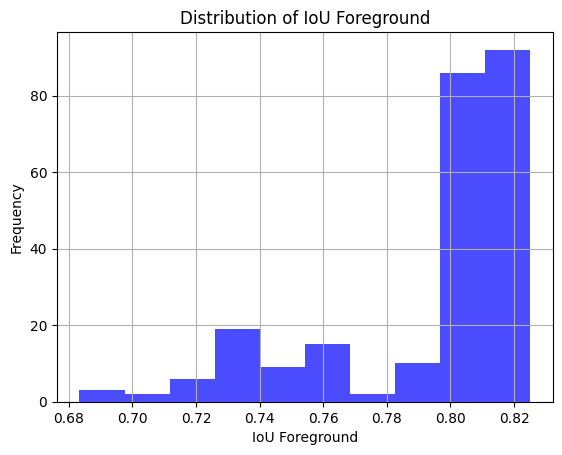

In [13]:
iou_dic = metrics_from_dataset(crf_sam95 , '/teamspace/studios/this_studio/Deeplab/pilot_annotations_eastafrica_haiti_freetown')

In [27]:
def get_overlayed_mask(checkpoint, to_download, use_url=False, my_bucket = None, save_binary_mask=False):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = load_deeplab_model(checkpoint, device).eval()
    img_path = '/teamspace/studios/this_studio/test.jpg'
    if use_url:
        
        urllib.request.urlretrieve(to_download, img_path)
        #!wget -q $to_download -O $img_path
    else:
        #my_bucket.download_file(to_download, '/teamspace/studios/this_studio/test.jpg')
        img_path = to_download  # Assuming `to_download` contains the local path in this case
    flip(img_path,img_path)
    img = Image.open(img_path).convert('RGB')
    img_transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    img_tensor = img_transform(img).unsqueeze(0).to(device, dtype=torch.float32)

    with torch.no_grad():
        output = model(img_tensor)
        output = torch.squeeze(output, dim=1)
        prob = torch.sigmoid(output).detach()
        pred = (prob > 0.5).long().cpu().numpy()[0]

    denorm = utils.Denormalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    img_np = img_tensor[0].detach().cpu().numpy()
    img_np = (denorm(img_np) * 255).transpose(1, 2, 0).astype(np.uint8)

    prob_np = prob[0].cpu().numpy()
    count = np.sum(prob_np > 0.5)
    confidence = np.sum(prob_np[prob_np > 0.5]) / count if count != 0 else 0
    
    if count == 0:
        print('Nothing detected')
    else:
        #print(plt.gcf()) 
        plt.figure(figsize=(10, 10))
        print('Confidence is ' + str(confidence))
        blue_mask = np.zeros_like(img_np)
        blue_mask[:, :, 2] = pred * 255 
        
        plt.imshow(img_np)
        plt.imshow(blue_mask, alpha=0.7)
        plt.axis('off')
        plt.gca().xaxis.set_major_locator(plt.NullLocator())
        plt.gca().yaxis.set_major_locator(plt.NullLocator())
        overlayed_path = os.path.join(os.getcwd(), 'test_overlayed.jpg')
        
        plt.savefig(overlayed_path, bbox_inches='tight', pad_inches=0)
        plt.show()
        plt.close()
        print('Overlayed Mask saved to ' + os.path.join(os.getcwd(), 'test_overlayed.jpg'))
        #show(overlayed_path)
    
    if save_binary_mask:
        pred_rgb = np.array(decode_target(pred)).astype(np.uint8)
        pred_image = Image.fromarray(pred_rgb).convert('RGB')
        pred_image.save(os.path.join(os.getcwd(), 'test_binary.jpg'))
        print('Binary Mask saved to ' + os.path.join(os.getcwd(), 'test_binary.jpg'))

def convert_sample_to_mask(sample_path):
    """
    Convert the given sample image path to the corresponding binary mask path.

    Parameters:
    sample_path (str): The file path of the sample image.

    Returns:
    str: The file path of the corresponding binary mask image.
    """
    # Split the path into its components
    path_parts = sample_path.split('/')

    # Change 'samples' to 'binary_masks'
    path_parts[-2] = 'binary_masks'

    # Change the filename extension from .jpg to _binarymask.jpg
    filename = path_parts[-1]
    base_name = filename.split('.')[0]
    new_filename = f"{base_name}_binarymask.jpg"

    # Replace the old filename with the new filename
    path_parts[-1] = new_filename

    # Join the parts back into a full path
    mask_path = '/'.join(path_parts)

    return mask_path

In [32]:

low_iou = {k: v for k, v in iou_dic.items() if v <= 0.7}
iou_list = [k for k, v in iou_dic.items() if v <= 0.75]
print(iou_list)

['/teamspace/studios/this_studio/Deeplab/pilot_annotations_eastafrica_haiti_freetown/samples/eastafrica_acactort_1_soilflag=0.jpg', '/teamspace/studios/this_studio/Deeplab/pilot_annotations_eastafrica_haiti_freetown/samples/eastafrica_acactort_5_soilflag=0.jpg', '/teamspace/studios/this_studio/Deeplab/pilot_annotations_eastafrica_haiti_freetown/samples/eastafrica_afzeliaa_1_soilflag=0.jpg', '/teamspace/studios/this_studio/Deeplab/pilot_annotations_eastafrica_haiti_freetown/samples/eastafrica_afzeliaa_6_soilflag=0.jpg', '/teamspace/studios/this_studio/Deeplab/pilot_annotations_eastafrica_haiti_freetown/samples/eastafrica_albziac_4_soilflag=0.jpg', '/teamspace/studios/this_studio/Deeplab/pilot_annotations_eastafrica_haiti_freetown/samples/eastafrica_albziac_5_soilflag=0.jpg', '/teamspace/studios/this_studio/Deeplab/pilot_annotations_eastafrica_haiti_freetown/samples/eastafrica_albziac_6_soilflag=0.jpg', '/teamspace/studios/this_studio/Deeplab/pilot_annotations_eastafrica_haiti_freetown/s

Device: cpu
Resume model from /teamspace/studios/this_studio/Deeplab/saved_models/crf_sam_large_freetown_eastafrica_haiti_sam_threshold_950.8867386284487256.pth
No ExifTags found: 'str' object has no attribute '_getexif'
Confidence is 0.8803661321738177


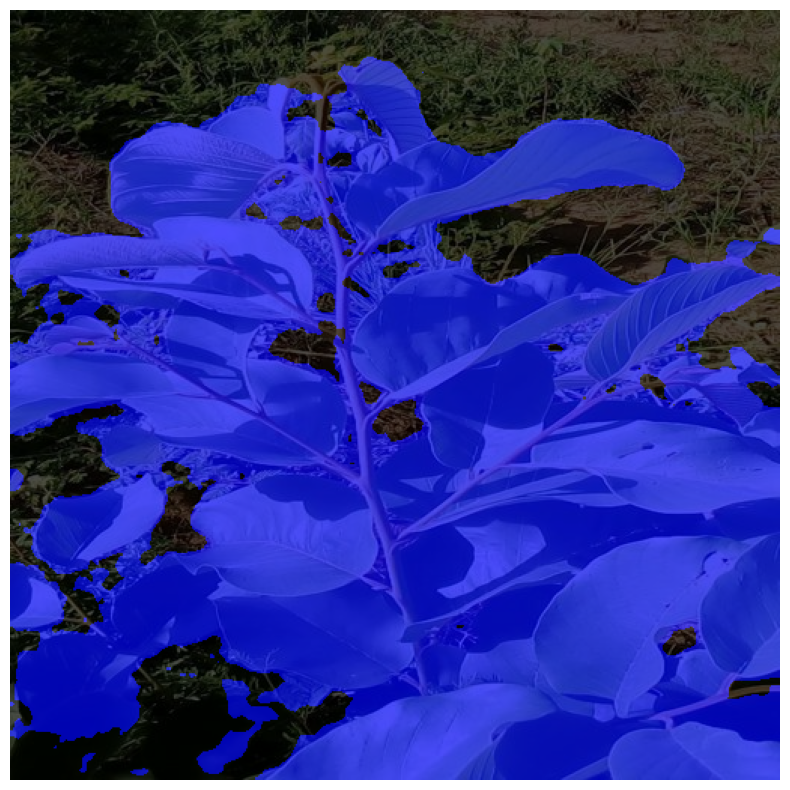

Overlayed Mask saved to /teamspace/studios/this_studio/Deeplab/test_overlayed.jpg


In [43]:
i = 6
get_overlayed_mask(crf_sam95,iou_list[i])

In [ ]:
show(convert_sample_to_mask(iou_list[i]))